In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

sns.set_theme(palette="colorblind")


def white_noise(obs=100, m=0, stdev=0.5, d=1):
    return np.random.normal(m, stdev, (obs, d)).flatten()

def red_noise(obs=100, m=0, stdev=0.5, d=1, corr=0.7):
    white = white_noise(obs, m, stdev, d)
    red = np.zeros_like(white)
    for i in range(1, len(white)):
        red[i] = corr * red[i-1] + white[i]
    return red

def xcorrelated(predictor, m=0, stdev=0.5, d=1, corr=0.7):
    white = white_noise(len(predictor), m, stdev, d)
    target = np.zeros_like(white)
    for i in range(1, len(white)):
        target[i] = corr * predictor[i-1] + white[i]
    return target

In [2]:
nobs =  30 
dates = pd.date_range(start="2024-01-01", periods=nobs)

predictor = red_noise(nobs)
target = xcorrelated(predictor, stdev=0.1, corr=0.9)

array([<Axes: >, <Axes: >], dtype=object)

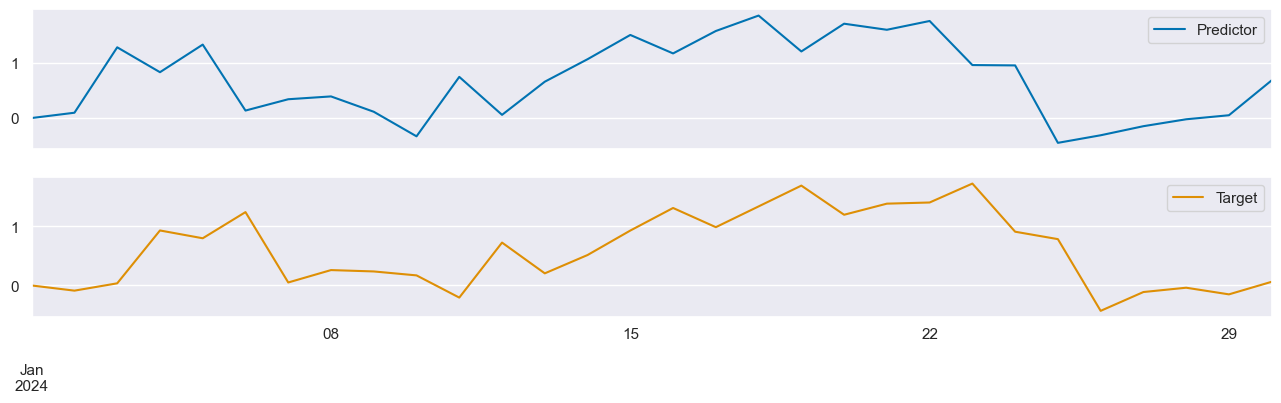

In [3]:
df = pd.DataFrame({"Predictor": predictor, "Target": target}, index=dates)
df.plot(subplots=True, sharex=True, figsize=(16,4), grid=True)

In [4]:
import statsmodels.api as sm

xcorrs = sm.tsa.stattools.ccf(target, predictor, adjusted=False)
# predictor's cross-correlation at lag 0, 1, 2, 3, and 4 with the target
# note the order of the arguments to the ccf function
xcorrs[:5]

array([0.64943335, 0.97294847, 0.63872544, 0.51347925, 0.25647548])

In [5]:
np.corrcoef(predictor, target)

array([[1.        , 0.64943335],
       [0.64943335, 1.        ]])

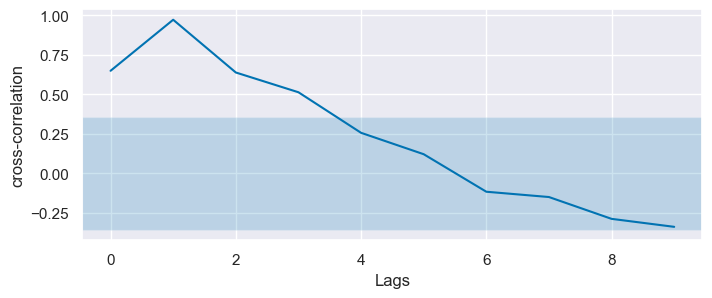

In [6]:
def build_ccf(y, x, max_lags=10):
    ccf_lags = sm.tsa.stattools.ccf(y, x, adjusted=False)
    plt.figure(figsize=[8, 3])
    lags = np.arange(max_lags) 
    ax = sns.lineplot(y=ccf_lags[:max_lags], x=lags)
    sign_band = 1.96 / np.sqrt(y.shape[0])
    plt.axhspan(-sign_band, sign_band, alpha=0.2)
    ax.set(xlabel='Lags', ylabel='cross-correlation')

build_ccf(target, predictor)

# Citing this notebook

If you use this notebook in your work, please cite it as follows:
    
Pekar, V. (2026). Business Forecasting. Lecture examples and exercises. (Version 1.0.0). URL: https://github.com/vpekar/bf